<a href="https://colab.research.google.com/github/anishah2505-star/appliance_energy_predictor/blob/main/app_energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2026-09-06 07:51:30.119 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 07:51:30.127 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 07:51:30.879 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-06 07:51:30.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 07:51:30.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 07:51:30.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 07:51:30.906 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

False

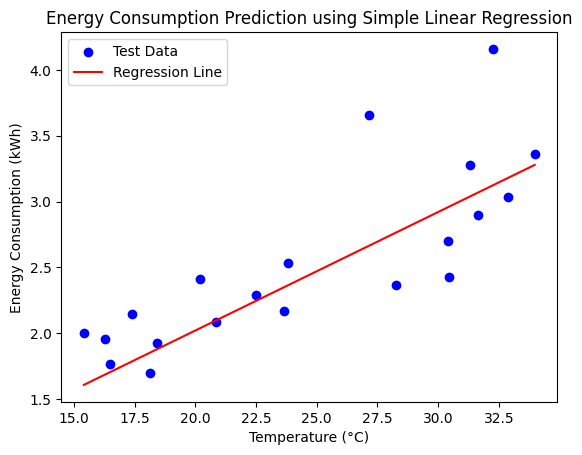

In [3]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import io

st.set_page_config(page_title="Appliance Energy Predictor", layout="centered")

st.title("🔌 Appliance Energy Consumption Predictor")
st.write(
    "Simple Linear Regression model that predicts **Energy Consumption (kWh)** "
    "from **Temperature (°C)**."
)

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
st.sidebar.header("Data")
uploaded_file = st.sidebar.file_uploader(
    "Upload appliance_energy.csv", type=["csv"]
)

DEFAULT_PATH = "appliance_energy.csv"

df = None
if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
else:
    try:
        df = pd.read_csv(DEFAULT_PATH)
        st.sidebar.info(f"Using bundled `{DEFAULT_PATH}` found alongside the app.")
    except FileNotFoundError:
        st.warning(
            "No dataset loaded yet. Please upload `appliance_energy.csv` "
            "using the sidebar to continue."
        )
        st.stop()

# ---------------------------------------------------------
# 2. Basic cleaning
# ---------------------------------------------------------
st.subheader("Dataset preview")
st.dataframe(df.head())

missing_before = df.isnull().sum().sum()
df = df.dropna()
if missing_before > 0:
    st.caption(f"Dropped rows with missing values ({missing_before} missing cells found).")

required_cols = ["Temperature (°C)", "Energy Consumption (kWh)"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    st.error(
        f"The uploaded file is missing required column(s): {missing_cols}. "
        f"Expected columns: {required_cols}"
    )
    st.stop()

# ---------------------------------------------------------
# 3. Train / test split + model training
# ---------------------------------------------------------
X = df[["Temperature (°C)"]]
y = df["Energy Consumption (kWh)"]

test_size = st.sidebar.slider("Test set size", 0.1, 0.5, 0.2, 0.05)
random_state = st.sidebar.number_input("Random state", value=42, step=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=int(random_state)
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# ---------------------------------------------------------
# 4. Show metrics
# ---------------------------------------------------------
st.subheader("Model performance")
col1, col2 = st.columns(2)
col1.metric("Mean Squared Error", f"{mse:.4f}")
col2.metric("R-Squared", f"{r2:.4f}")

st.write(
    f"**Equation:** Energy = {model.coef_[0]:.4f} × Temperature + {model.intercept_:.4f}"
)

# ---------------------------------------------------------
# 5. Plot regression line
# ---------------------------------------------------------
st.subheader("Regression fit on test data")
fig, ax = plt.subplots()
ax.scatter(X_test, y_test, color="blue", label="Test Data")
sort_idx = X_test.values[:, 0].argsort()
ax.plot(
    X_test.values[sort_idx, 0],
    y_pred[sort_idx],
    color="red",
    label="Regression Line",
)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Energy Consumption (kWh)")
ax.set_title("Energy Consumption Prediction using Simple Linear Regression")
ax.legend()
st.pyplot(fig)

# ---------------------------------------------------------
# 6. Interactive prediction
# ---------------------------------------------------------
st.subheader("Try a prediction")
temp_input = st.number_input(
    "Enter a temperature (°C):",
    value=float(X["Temperature (°C)"].mean()),
    step=0.5,
)
if st.button("Predict energy consumption"):
    pred = model.predict(pd.DataFrame({"Temperature (°C)": [temp_input]}))[0]
    st.success(f"Predicted Energy Consumption: **{pred:.2f} kWh**")

# ---------------------------------------------------------
# 7. Download trained model
# ---------------------------------------------------------
st.subheader("Download trained model")
model_buffer = io.BytesIO()
joblib.dump(model, model_buffer)
model_buffer.seek(0)
st.download_button(
    label="Download model (.pkl)",
    data=model_buffer,
    file_name="appliance_energy_model.pkl",
    mime="application/octet-stream",
)